In [1]:
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize, LogNorm
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.pyplot as plt
import scqubits
from tqdm import tqdm
from IPython.display import clear_output
from functools import partial
import matplotlib


In [21]:
def second_order_derivative(f, x0, rtol=1e-3, atol=1e-4, max_iter=20):
    h = 1e-3
    derivative_old = 0.0
    print('\n')
    for i in range(max_iter):
        h /= 2
        derivative_new = (f(x0 + h) - 2 * f(x0) + f(x0 - h)) / h**2
        print(derivative_new)
        if np.abs(derivative_new - derivative_old) < rtol*np.abs(derivative_old):
            return derivative_new
        derivative_old = derivative_new
    raise ValueError("Convergence not reached within the maximum number of iterations")

def first_order_derivative(f, x0, rtol=1e-3, atol=1e-4, max_iter=20):
    h = 1e-3
    derivative_old = 0.0
    print('\n')
    for i in range(max_iter):
        h /= 2
        derivative_new = (f(x0 + h) - f(x0 - h)) / (2 * h)
        print(derivative_new)
        if np.abs(derivative_new - derivative_old) < rtol * np.abs(derivative_old):
            return derivative_new
        derivative_old = derivative_new
    raise ValueError("Convergence not reached within the maximum number of iterations")


def get_frequency(flux,EJ,EC,EL,i,j):
    qbt = scqubits.Fluxonium(EJ = EJ,EC = EC,EL =EL, cutoff = 110,flux = flux,truncated_dim=20)
    vals = qbt.eigenvals()
    return np.abs(vals[j]-vals[i])


hbar = 1/(2*np.pi)
kB = 8.617333262e-5  # eV K−1
hbar_in_eVs = 6.5821e-16  # eV s
temp_in_mK = 20
 
def diel_spectral_density(omega, EC,temp_in_mK = 20 ,tangent_ref = 1e-5):
    beta = 1 / (kB * temp_in_mK * 1e-3)  # 1/eV

    coth_arg = beta * hbar_in_eVs * np.abs(omega) / 2  # s GHZ
    coth_arg *= 1e9  # dimensionless
    return_val = np.where(omega < 0, 
                          1/2 * np.abs( 1 / np.tanh(coth_arg) - 1) , 
                          1/2 * np.abs( 1 / np.tanh(coth_arg) + 1) )

    omega_ref = 2*np.pi *6 # GHz
    epsilon = 0.15
    Q_cap = 1/(  2* tangent_ref * np.abs(omega/omega_ref)**epsilon ) 

    return_val *= hbar * np.abs(omega)**2   / (4 * EC * Q_cap)  # GHZ^2/GHZ = GHZ
    return return_val

def one_over_f_spectral_density(omega, EL,one_over_f_flux_noise_amplitude ):
    return_val = 2 * np.pi # dimensionless
    return_val *= (EL / hbar)**2  # GHz^2
    return_val *= one_over_f_flux_noise_amplitude**2  # GHz^2
    return_val /= omega  # GHz
    return np.abs(return_val)

def T_phi(second_order_derivative, one_over_f_flux_noise_amplitude, first_order_derivative= 0 ):  # eqn (13) of Peter Groszkowski et al 2018 New J. Phys. 20 043053
    omega_uv = 3 * 2 * np.pi  # GHz
    omega_ir = 1e-9 * 2 * np.pi  # GHz
    t = 10e3  # ns
    A = one_over_f_flux_noise_amplitude  # in unit of Phi0

    first_order_part = 2 * A**2 * first_order_derivative**2
    first_order_part *= np.abs(np.log(omega_ir * t))

    second_order_part = 2 * A**4 * second_order_derivative**2  # Phi0^4 GHZ^2 / Phi0^4
    second_order_part *= (np.log(omega_uv / omega_ir)**2 + 2 * np.log(omega_ir * t)**2)  # GHZ^2
    return (first_order_part + second_order_part)  **(-1/2)  # ns


In [25]:
tangent = 4e-6
eta = 1e-6


UIFQ_diel_T1_array = []
UIFQ_1overf_T1_array = []
UIFQ_T1_array = []
gf_Tphi_array = []
gf_diel_T1_array = []
gf_1overf_T1_array = []
gf_T1_array = []

def get_data(flux):
    EJ = 3
    EJoverEC = 3
    EJoverEL = 30
    EC = EJ / EJoverEC
    EL = EJ / EJoverEL

    IFQ = scqubits.Fluxonium(EJ = EJ,EC = EJ/EJoverEC,EL = EJ/EJoverEL, cutoff =110,flux = flux,truncated_dim=20)
    UIFQ_element = np.abs(IFQ.matrixelement_table('phi_operator',evals_count=3)[1,2]) 
    UIFQ_freq = (IFQ.eigenvals()[2]-IFQ.eigenvals()[1]) * 2 * np.pi
    UIFQ_dielectric_lifetime = 1 / (np.abs(UIFQ_element)**2 * diel_spectral_density(UIFQ_freq, EC,temp_in_mK,tangent)) / 1e6
    UIFQ_one_over_f_loss_lifetime = 1 / (np.abs(UIFQ_element)**2 * one_over_f_spectral_density(UIFQ_freq, EL,eta ))  / 1e6
    
    gf_1st_derivative = first_order_derivative(partial(get_frequency, EJ = EJ,EC = EJ/EJoverEC,EL=EJ/EJoverEL,i=0,j=2),x0=flux)
    gf_2nd_derivative = second_order_derivative(partial(get_frequency, EJ = EJ,EC = EJ/EJoverEC,EL=EJ/EJoverEL,i=0,j=2),x0=flux)
    gf_dephasing_lifetime = T_phi(gf_2nd_derivative, eta,gf_1st_derivative) / 1e6

    gf_element = np.abs(IFQ.matrixelement_table('phi_operator',evals_count=3)[0,2]) 
    gf_freq = (IFQ.eigenvals()[2]-IFQ.eigenvals()[0]) * 2 * np.pi
    gf_dielectric_lifetime = 1 / (np.abs(gf_element)**2 * diel_spectral_density(gf_freq, EC,temp_in_mK,tangent)) / 1e6
    gf_one_over_f_loss_lifetime = 1 / (np.abs(gf_element)**2 * one_over_f_spectral_density(gf_freq, EL,eta ))  / 1e6

    return UIFQ_dielectric_lifetime, UIFQ_one_over_f_loss_lifetime, gf_dephasing_lifetime, gf_dielectric_lifetime, gf_one_over_f_loss_lifetime
flux_array = np.logspace(-6, -1, num=30)
for flux in tqdm(flux_array,desc='looping'):
    UIFQ_dielectric_lifetime, UIFQ_one_over_f_loss_lifetime, gf_dephasing_lifetime, gf_dielectric_lifetime, gf_one_over_f_loss_lifetime = get_data(flux)
    UIFQ_T1 = 1/(1/UIFQ_dielectric_lifetime + 1/UIFQ_one_over_f_loss_lifetime)
    gf_T1 = 1/(1/gf_dielectric_lifetime + 1/gf_one_over_f_loss_lifetime)
    UIFQ_diel_T1_array.append(UIFQ_dielectric_lifetime)
    UIFQ_1overf_T1_array.append(UIFQ_one_over_f_loss_lifetime)
    gf_diel_T1_array.append(gf_dielectric_lifetime)
    gf_1overf_T1_array.append(gf_one_over_f_loss_lifetime)
    UIFQ_T1_array.append(UIFQ_T1)
    gf_T1_array.append(gf_T1)
    gf_Tphi_array.append(gf_dephasing_lifetime)

looping:   0%|          | 0/30 [00:00<?, ?it/s]



0.0009683865542786663
0.0009747732874210158
0.0009763898729531206
0.0009767952171557681


972.6396851919006
975.8506354877738
976.6600181393414


looping:   3%|▎         | 1/30 [00:00<00:24,  1.18it/s]



0.0014403316912492414
0.0014498310414445825
0.0014522354385704261
0.0014528382443756982


972.6395619313877


looping:   7%|▋         | 2/30 [00:01<00:21,  1.30it/s]

...

looping:  93%|█████████▎| 28/30 [00:16<00:01,  1.97it/s]

0.37125751539690555
0.3712071929840022


3.652779299799569
3.6527795909115923


-0.050103682980306985
-0.05011081327666034


looping:  97%|█████████▋| 29/30 [00:17<00:00,  1.81it/s]



3.647667403581245
3.647667525075171


-0.23466847309805416
-0.23466869691901593


looping: 100%|██████████| 30/30 [00:19<00:00,  1.56it/s]


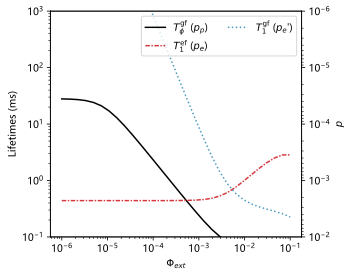

In [29]:
fig = plt.figure(figsize=(5, 3.7)) 
gs = fig.add_gridspec(nrows=1, ncols=1,left=0.15, right=0.85,bottom=0.12,top = 0.97)
ax = fig.add_subplot(gs[0])


ax.plot( flux_array, gf_Tphi_array, color= 'black',label = rf'$T_\phi^\text{{gf}}$ ($p_p$)',linestyle='-')
# ax.plot( flux_array, UIFQ_diel_T1_array, color= '#d5373d',label = rf'$T_1^\text{{ef diel}}$',linestyle='--')
# ax.plot( flux_array, UIFQ_1overf_T1_array, color= '#4999c3',label = rf'$T_1^\text{{ef 1/f}}$',linestyle=':')
ax.plot( flux_array, UIFQ_T1_array, color= '#d5373d',label = rf'$T_1^\text{{ef}}$ ($p_e$)',linestyle=(0,(3,1,1,1)))

# ax.plot( flux_array, gf_diel_T1_array, color= '#d5373d',label = rf'$T_1^\text{{gf diel}}$',linestyle='--')
# ax.plot( flux_array, gf_1overf_T1_array, color= '#4999c3',label = rf'$T_1^\text{{gf 1/f}}$',linestyle=':')
ax.plot( flux_array, gf_T1_array, color= '#4999c3',label = rf"$T_1^\text{{gf}}$ ($p_e$')",linestyle=':')

ymin = 1e-1
ymax = 1e3
ax.set_ylim(ymin, ymax)

ax2 = ax.twinx()
ax2.set_ylabel(r'$p$')
ax2.set_ylim(1e-3/ymin,1e-3/ymax)
ax2.set_yscale('log')
# y_ticks_lifetimes = ax.get_yticks()
# secax_y = ax.secondary_yaxis('right')
# secax_y.set_ylabel(r'$p_e$')
# secax_y.set_yticks(y_ticks_lifetimes,labels=[f'{1e-3 * val:.2e}' for val in y_ticks_lifetimes])

# ax2.set_yticks(y_ticks_lifetimes,labels=[f'{1e-3 / val:.2e}' for val in y_ticks_lifetimes])

# ax.text(3.2,1e-2,'Erasure not tolerable for GigaQuop at d=13',color= 'black',size = 11)

# ax.text(1,1e4,r'''
# Choose highest $p_p$
# with tolerable erasure
# ''',color= 'black',size = 11)
ax.set_xscale('log')

ax.set_yscale('log')
ax.set_xlabel(r'$\Phi_{ext}$')
ax.set_ylabel(r'Lifetimes (ms)')
ax.legend(ncol = 2,loc='upper right')
fig.savefig('gf_sensitivity.pdf')